## Problem Statement:
### You are hired by a company Gem Stones co ltd, which is a cubic zirconia manufacturer. You are provided with the dataset containing the prices and other attributes of almost 27,000 cubic zirconia (which is an inexpensive diamond alternative with many of the same qualities as a diamond). The company is earning different profits on different prize slots. You have to help the company in predicting the price for the stone on the basis of the details given in the dataset so it can distinguish between higher profitable stones and lower profitable stones so as to have a better profit share. Also, provide them with the best 5 attributes that are most important.

## Task you can perform 📝
1. 📌 Clean and preprocess the data.
2. 📌 Do Exploratory Data Analysis (EDA) to get some insight into data.
3. 📌 Do Feature Engineering.
4. 📌 Build a model i.e Regression Analysis.
5. 📌 Evaluate the model.
6. 📌 Go back to any of the previous steps unless the result is sufficient.

In [1]:
# Data ingestion

In [2]:
import pandas as pd
import numpy as np

In [3]:

df_original = pd.read_csv("E://Python Projects//ML//Diamond Price Prediction//notebooks//data//cubic_zirconia.csv")

In [4]:
df_original

,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z,price
0,1,0.30,Ideal,E,SI1,62.1,58.0,4.27,4.29,2.66,499
1,2,0.33,Premium,G,IF,60.8,58.0,4.42,4.46,2.70,984
2,3,0.90,Very Good,E,VVS2,62.2,60.0,6.04,6.12,3.78,6289
3,4,0.42,Ideal,F,VS1,61.6,56.0,4.82,4.80,2.96,1082
4,5,0.31,Ideal,F,VVS1,60.4,59.0,4.35,4.43,2.65,779
...,...,...,...,...,...,...,...,...,...,...,...
26962,26963,1.11,Premium,G,SI1,62.3,58.0,6.61,6.52,4.09,5408
26963,26964,0.33,Ideal,H,IF,61.9,55.0,4.44,4.42,2.74,1114
26964,26965,0.51,Premium,E,VS2,61.7,58.0,5.12,5.15,3.17,1656
26965,26966,0.27,Very Good,F,VVS2,61.8,56.0,4.19,4.20,2.60,682


In [5]:
df_original.shape

(26967, 11)

In [6]:
df_original.size

296637

In [7]:
df_original.describe()

,Unnamed: 0,carat,depth,table,x,y,z,price
count,26967.000000,26967.000000,26270.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000
mean,13484.000000,0.798375,61.745147,57.456080,5.729854,5.733569,3.538057,3939.518115
std,7784.846691,0.477745,1.412860,2.232068,1.128516,1.166058,0.720624,4024.864666
min,1.000000,0.200000,50.800000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,6742.500000,0.400000,61.000000,56.000000,4.710000,4.710000,2.900000,945.000000
50%,13484.000000,0.700000,61.800000,57.000000,5.690000,5.710000,3.520000,2375.000000
75%,20225.500000,1.050000,62.500000,59.000000,6.550000,6.540000,4.040000,5360.000000
max,26967.000000,4.500000,73.600000,79.000000,10.230000,58.900000,31.800000,18818.000000


In [8]:
df_original.isnull().sum()

Unnamed: 0      0
carat           0
cut             0
color           0
clarity         0
depth         697
table           0
x               0
y               0
z               0
price           0
dtype: int64

Only values from deepth are missing

In [9]:
df_original.duplicated().sum()

np.int64(0)

In [10]:
df_original.isna().sum()

Unnamed: 0      0
carat           0
cut             0
color           0
clarity         0
depth         697
table           0
x               0
y               0
z               0
price           0
dtype: int64

In [11]:

num_data = df_original.select_dtypes(include='number')

In [12]:
cat_data = df_original.select_dtypes(include=['object','category'])

In [13]:
num_data.corr()

,Unnamed: 0,carat,depth,table,x,y,z,price
Unnamed: 0,1.000000,0.003490,-0.001588,0.003817,0.004626,0.006844,0.001681,0.002650
carat,0.003490,1.000000,0.035364,0.181685,0.976368,0.941071,0.940640,0.922416
depth,-0.001588,0.035364,1.000000,-0.298011,-0.018715,-0.024735,0.101624,-0.002569
table,0.003817,0.181685,-0.298011,1.000000,0.196206,0.182346,0.148944,0.126942
x,0.004626,0.976368,-0.018715,0.196206,1.000000,0.962715,0.956606,0.886247
y,0.006844,0.941071,-0.024735,0.182346,0.962715,1.000000,0.928923,0.856243
z,0.001681,0.940640,0.101624,0.148944,0.956606,0.928923,1.000000,0.850536
price,0.002650,0.922416,-0.002569,0.126942,0.886247,0.856243,0.850536,1.000000


In [14]:
df_original.nunique()

Unnamed: 0    26967
carat           257
cut               5
color             7
clarity           8
depth           169
table           112
x               531
y               526
z               356
price          8742
dtype: int64

In [15]:
num_data

,Unnamed: 0,carat,depth,table,x,y,z,price
0,1,0.30,62.1,58.0,4.27,4.29,2.66,499
1,2,0.33,60.8,58.0,4.42,4.46,2.70,984
2,3,0.90,62.2,60.0,6.04,6.12,3.78,6289
3,4,0.42,61.6,56.0,4.82,4.80,2.96,1082
4,5,0.31,60.4,59.0,4.35,4.43,2.65,779
...,...,...,...,...,...,...,...,...
26962,26963,1.11,62.3,58.0,6.61,6.52,4.09,5408
26963,26964,0.33,61.9,55.0,4.44,4.42,2.74,1114
26964,26965,0.51,61.7,58.0,5.12,5.15,3.17,1656
26965,26966,0.27,61.8,56.0,4.19,4.20,2.60,682


In [16]:
num_data.describe()

,Unnamed: 0,carat,depth,table,x,y,z,price
count,26967.000000,26967.000000,26270.000000,26967.000000,26967.000000,26967.000000,26967.000000,26967.000000
mean,13484.000000,0.798375,61.745147,57.456080,5.729854,5.733569,3.538057,3939.518115
std,7784.846691,0.477745,1.412860,2.232068,1.128516,1.166058,0.720624,4024.864666
min,1.000000,0.200000,50.800000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,6742.500000,0.400000,61.000000,56.000000,4.710000,4.710000,2.900000,945.000000
50%,13484.000000,0.700000,61.800000,57.000000,5.690000,5.710000,3.520000,2375.000000
75%,20225.500000,1.050000,62.500000,59.000000,6.550000,6.540000,4.040000,5360.000000
max,26967.000000,4.500000,73.600000,79.000000,10.230000,58.900000,31.800000,18818.000000


In [17]:
cat_data

,cut,color,clarity
0,Ideal,E,SI1
1,Premium,G,IF
2,Very Good,E,VVS2
3,Ideal,F,VS1
4,Ideal,F,VVS1
...,...,...,...
26962,Premium,G,SI1
26963,Ideal,H,IF
26964,Premium,E,VS2
26965,Very Good,F,VVS2


In [18]:
cat_data.describe()

,cut,color,clarity
count,26967,26967,26967
unique,5,7,8
top,Ideal,G,SI1
freq,10816,5661,6571


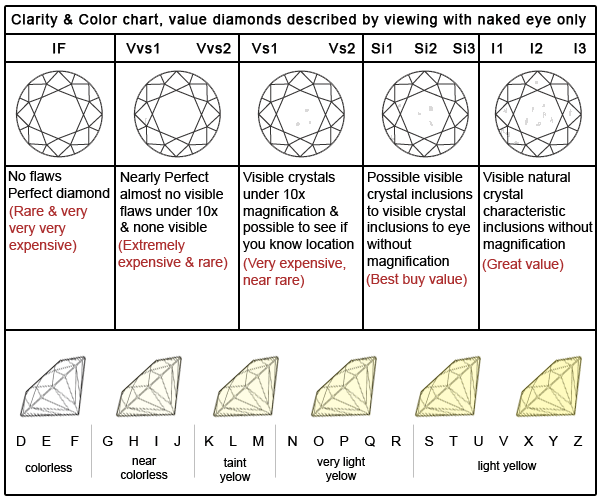

# EDA anaiysis

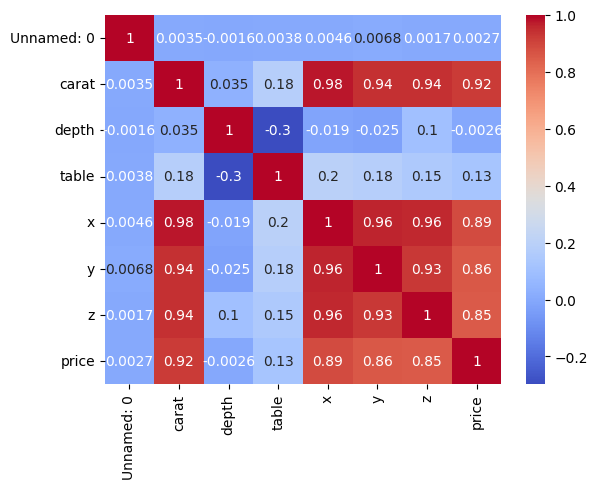

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = num_data.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='carat'>

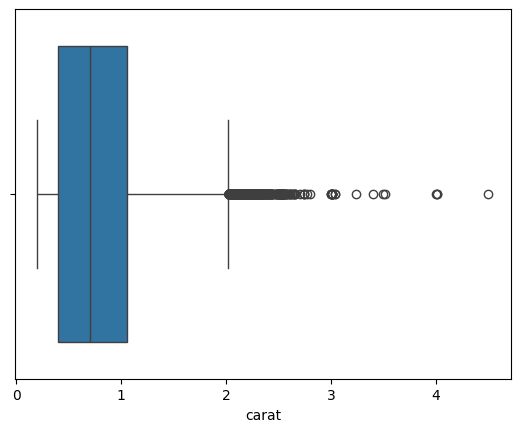

In [20]:
sns.boxplot(x=df_original['carat'])

<function matplotlib.pyplot.show(close=None, block=None)>

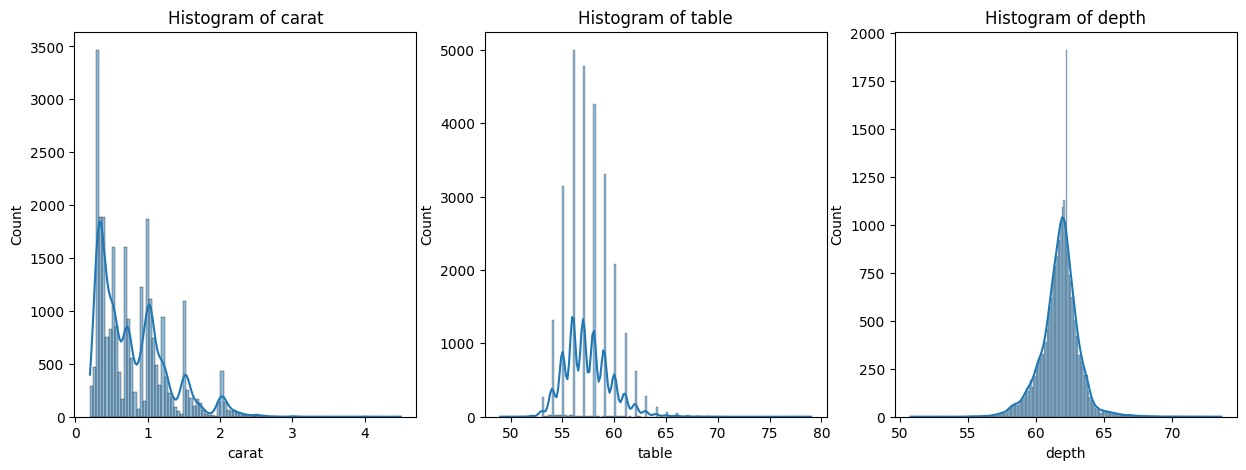

In [21]:
f,ax = plt.subplots(1,3,figsize=[15,5])

# Title of grapha
ax[0].set_title("Histogram of carat")
ax[1].set_title("Histogram of table")
ax[2].set_title("Histogram of depth")

sns.histplot(data=num_data,x=num_data['carat'],kde=True,ax=ax[0])
sns.histplot(data=num_data,x=num_data['table'],kde=True,ax=ax[1])
sns.histplot(data=num_data,x=num_data['depth'],kde=True,ax=ax[2])

plt.tight_layout
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

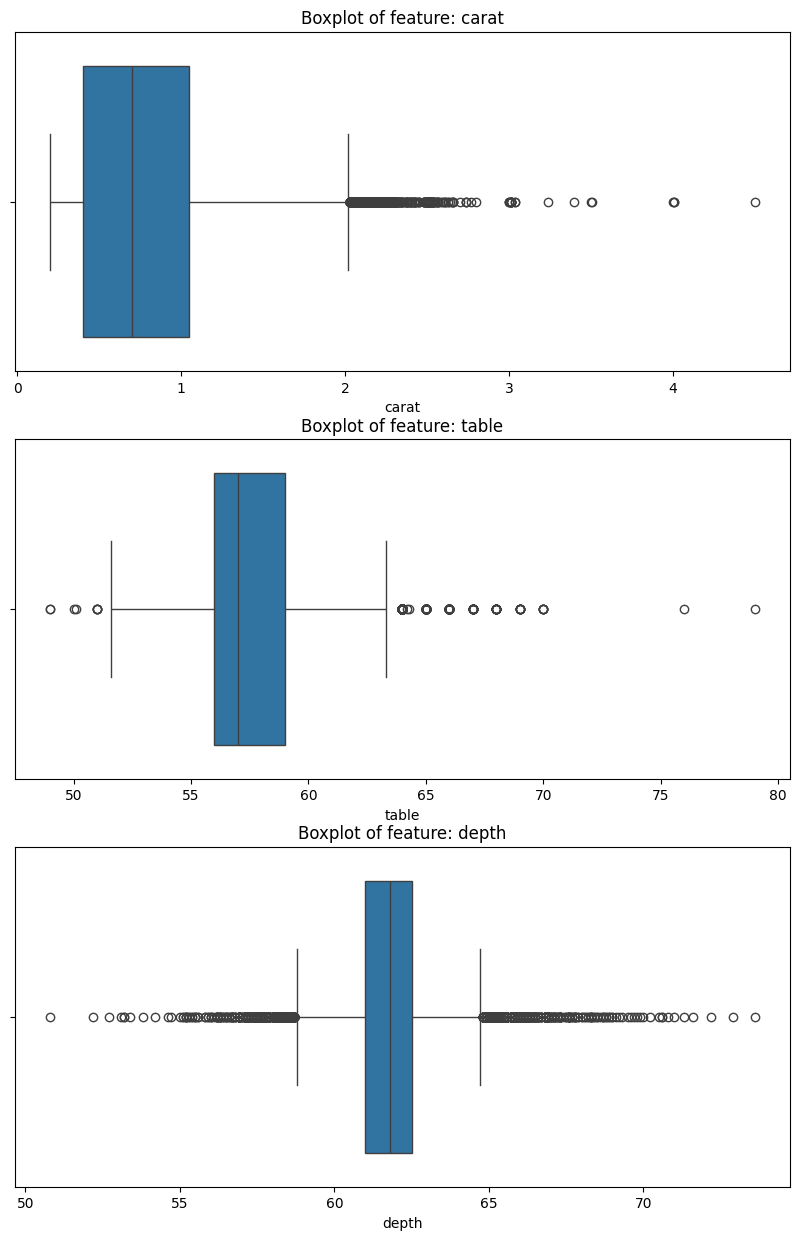

In [22]:
f,ax = plt.subplots(3,1,figsize=[10,15])

ax[0].set_title("Boxplot of feature: carat")
ax[1].set_title("Boxplot of feature: table")
ax[2].set_title("Boxplot of feature: depth")

sns.boxplot(data=df_original,x=df_original['carat'],ax=ax[0])
sns.boxplot(data=df_original,x=df_original['table'],ax=ax[1])
sns.boxplot(data=df_original,x=df_original['depth'],ax=ax[2])

plt.tight_layout
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

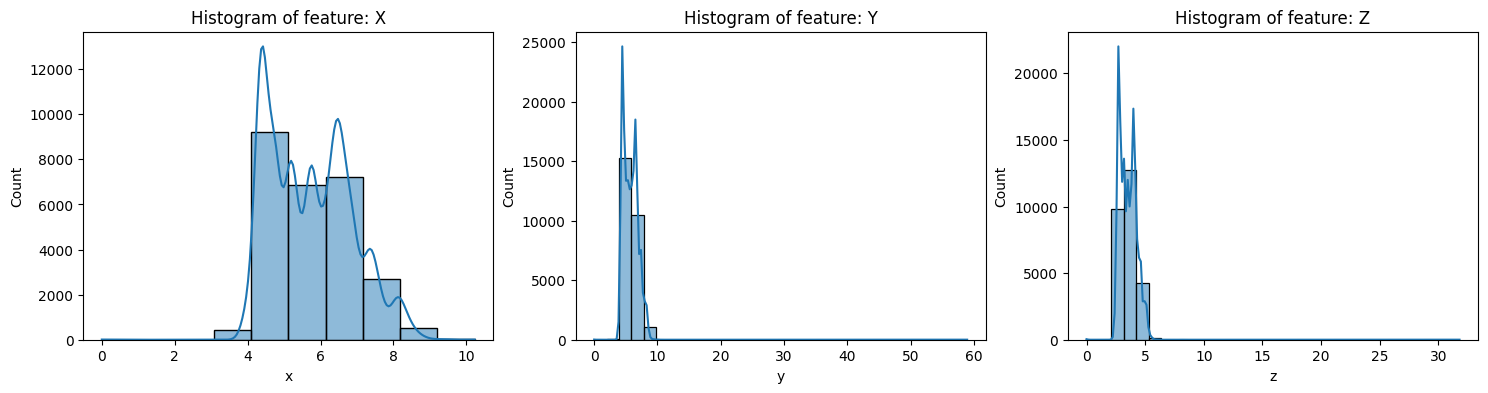

In [23]:
f,ax = plt.subplots(1,3,figsize=[18,4])

ax[0].set_title("Histogram of feature: X")
ax[1].set_title("Histogram of feature: Y")
ax[2].set_title("Histogram of feature: Z")

sns.histplot(data=df_original,x=df_original['x'],kde=True,ax=ax[0],bins=10)
sns.histplot(data=df_original,x=df_original['y'],kde=True,ax=ax[1],bins=30)
sns.histplot(data=df_original,x=df_original['z'],kde=True,ax=ax[2],bins=30)

plt.tight_layout
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

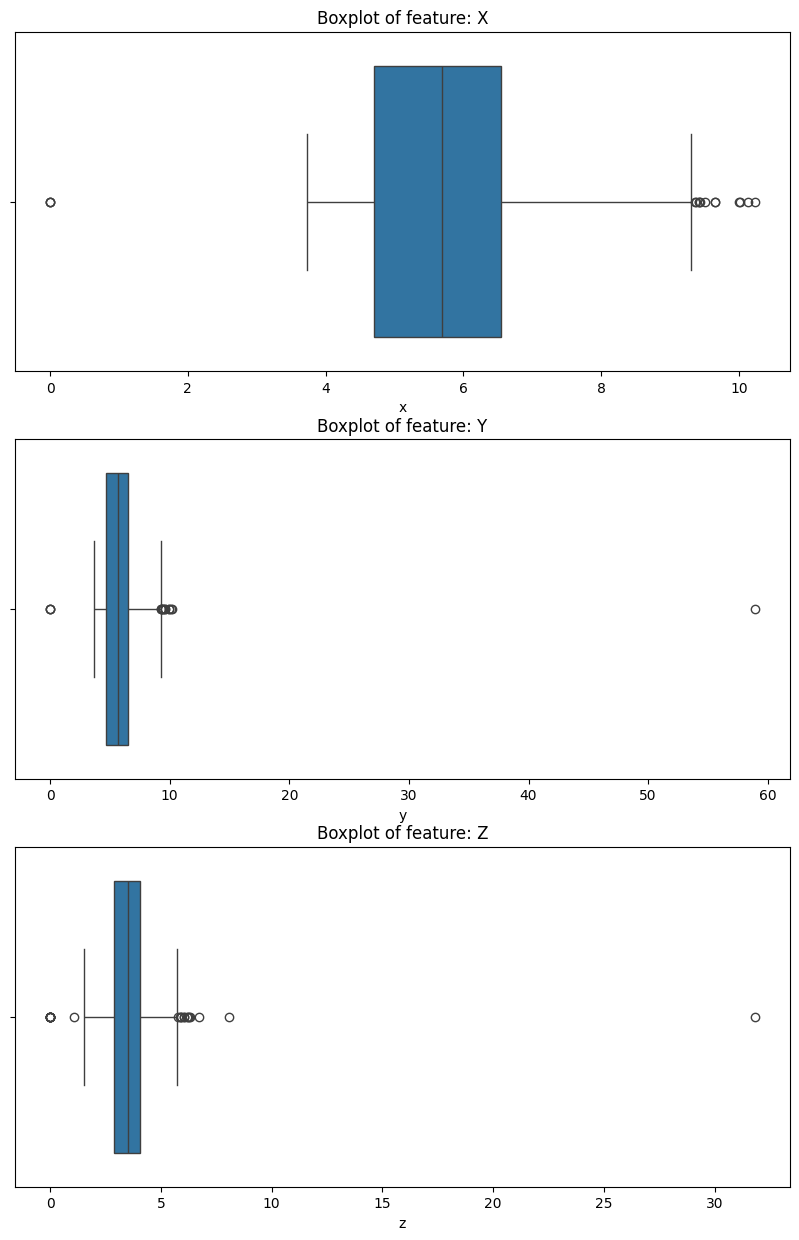

In [24]:
f,ax = plt.subplots(3,1,figsize=[10,15])

ax[0].set_title("Boxplot of feature: X")
ax[1].set_title("Boxplot of feature: Y")
ax[2].set_title("Boxplot of feature: Z")

sns.boxplot(data=df_original,x=df_original['x'],ax=ax[0])
sns.boxplot(data=df_original,x=df_original['y'],ax=ax[1])
sns.boxplot(data=df_original,x=df_original['z'],ax=ax[2])

plt.tight_layout
plt.show

In [25]:
cat_data.describe()


,cut,color,clarity
count,26967,26967,26967
unique,5,7,8
top,Ideal,G,SI1
freq,10816,5661,6571


In [26]:
print(cat_data['color'].value_counts())
print(cat_data['clarity'].value_counts())
print(cat_data['cut'].value_counts())

color
G    5661
E    4917
F    4729
H    4102
D    3344
I    2771
J    1443
Name: count, dtype: int64
clarity
SI1     6571
VS2     6099
SI2     4575
VS1     4093
VVS2    2531
VVS1    1839
IF       894
I1       365
Name: count, dtype: int64
cut
Ideal        10816
Premium       6899
Very Good     6030
Good          2441
Fair           781
Name: count, dtype: int64


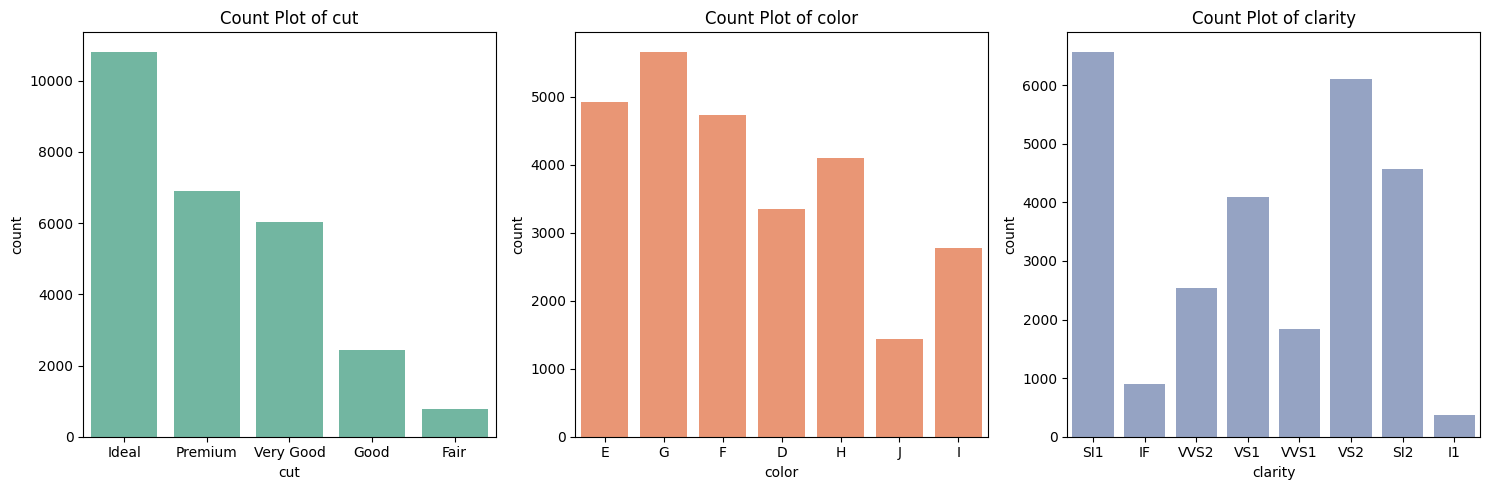

In [27]:
n =len(cat_data.columns)

palette = sns.color_palette("Set2", n)

f,ax= plt.subplots(1,n,figsize=[15,5])
count=0

for i in cat_data:
    ax[count].set_title(f"Count Plot of {i}")
    sns.countplot(data=cat_data,x=i,ax=ax[count],color=palette[count])
    count +=1

plt.tight_layout()
plt.show()

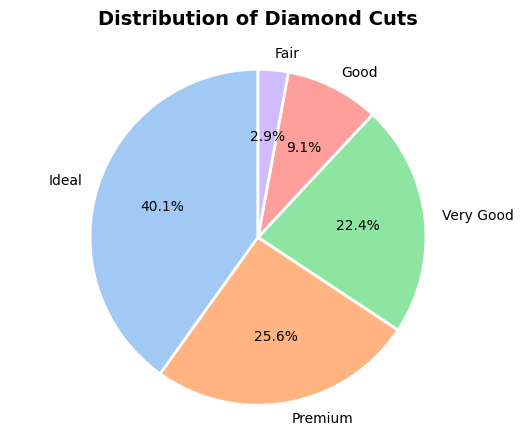

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Choose your categorical column (e.g., 'cut') and get the counts
# Sorting ensures the largest slices are organized cleanly
cat_counts = df_original['cut'].value_counts()

# 2. Set a beautiful color palette using Seaborn
colors = sns.color_palette('pastel')[0:len(cat_counts)]

# 3. Create the pie plot
plt.pie(
    cat_counts, 
    labels=cat_counts.index, 
    autopct='%1.1f%%',      # Displays percentages cleanly (e.g., "25.3%")
    startangle=90,          # Rotates the start to make it look balanced
    colors=colors,
    wedgeprops={"edgecolor": "white", 'linewidth': 2, 'antialiased': True} # Clean white borders
)

# 4. Final adjustments to ensure text is fully readable and not truncated
plt.title("Distribution of Diamond Cuts", fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')  # Ensures the pie chart is rendered as a perfect circle

# Display the plot in your VS Code notebook window
plt.show()

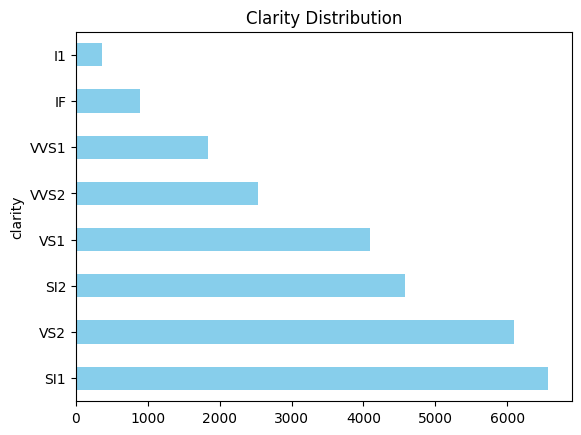

In [29]:
df_original['clarity'].value_counts().plot(kind='barh', color='skyblue')
plt.title('Clarity Distribution')
plt.show()

<Axes: xlabel='carat', ylabel='price'>

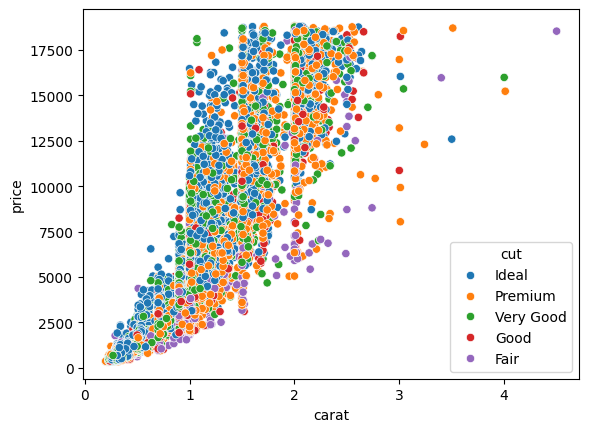

In [30]:
sns.scatterplot(x=df_original['carat'], y=df_original['price'],hue=df_original['cut'])

In [31]:
import scipy.stats as stats

# Group price by the distinct categories of 'cut'
groups = [group['price'].values for name, group in df_original.groupby('cut')]

# Run One-Way ANOVA
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-Statistic: {f_stat}, P-Value: {p_value}")

F-Statistic: 85.61819538919742, P-Value: 2.1478344018991011e-72


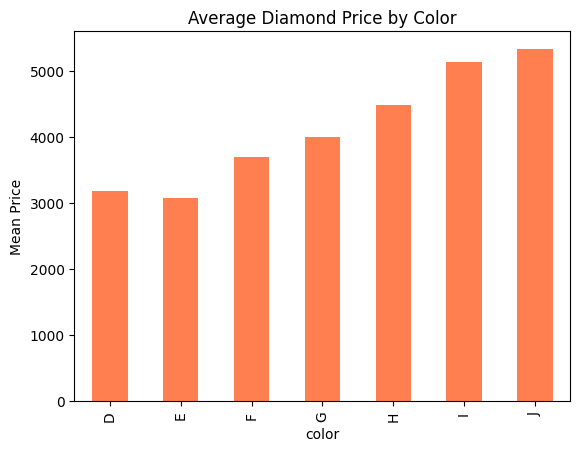

In [32]:
# Check the average price for each category group
df_original.groupby('color')['price'].mean().plot(kind='bar', color='coral')
plt.ylabel('Mean Price')
plt.title('Average Diamond Price by Color')
plt.show()

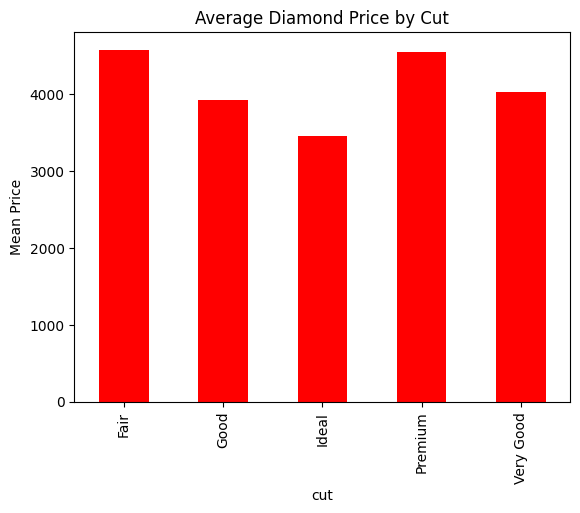

In [33]:
# Check the average price for each category group
df_original.groupby('cut')['price'].mean().plot(kind='bar',color='red')
plt.ylabel('Mean Price')
plt.title('Average Diamond Price by Cut')
plt.show()

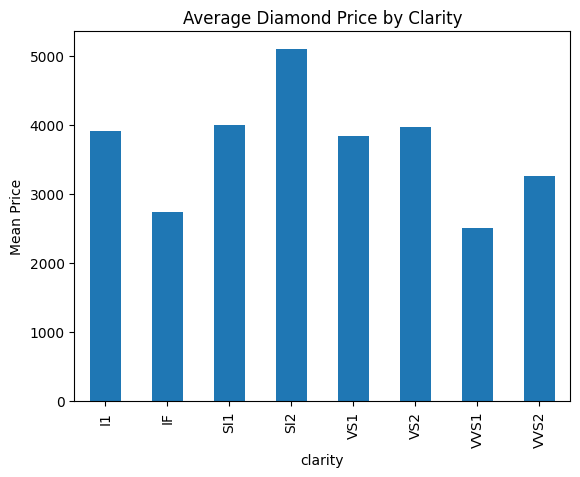

In [34]:
df_original.groupby('clarity')['price'].mean().plot(kind='bar')
plt.ylabel('Mean Price')
plt.title('Average Diamond Price by Clarity')
plt.show()

In [ ]:
import scipy.stats as stats

# Group price by the distinct categories of 'cut'
groups = [group['price'].values for name, group in df_original.groupby('cut')]

# Run One-Way ANOVA
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-Statistic: {f_stat}, P-Value: {p_value}")

In [54]:
group= [group['price'].values for name,group in df_original.groupby('clarity')]

In [ ]:
def annova_for_catagorical(df:pd.DataFrame,catagorical_col:str,targeet_column:str):
    